# Certification reputation as market infrastructure — numerical companion
### Brand safety & ad verification

**Arthus Goujon**

This notebook is the applied companion to the paper *"Reputation disciplines information, not licenses."*
It turns the model into a small, interpretable simulation calibrated to **ad verification / brand safety**, and derives two testable predictions in ad-tech language.

**One-line model.** A label (a "verified / brand-safe" flag, a quality badge, a rating) is valued for two reasons:
an **informational** value — people *believe* it and act on it — and a **license / access** value — it mechanically
unlocks demand (mandated spend, ranking eligibility, liability cover), *independently of belief*. The two react in
opposite ways to a scandal: informational reliance collapses, license reliance persists. Reputation only disciplines
what the scandal destroys. Hence: **the larger the license share of a label, the less private reputation can discipline it.**

**Why ad verification is the cleanest instance.** Verification vendors (e.g. DoubleVerify, IAS) certify inventory as
brand-safe / viewable / non-fraudulent. Advertisers mandate buying *verified* inventory and use it partly as
compliance / "plausible deniability." That mandated demand is the **license** component: it does not vanish when the
vendor is shown to have missed fraud — which is exactly when reputation should bite, and doesn't.


## 1. Model objects

- Prior the asset (impression/placement) is good: $\mu_0$. Sophisticated demand after posterior $\mu$: $F(\mu)$ (we take $F=\mathrm{id}$).
- Reliance splits into informational $\beta_I$ and license $\beta_L$, total $\beta$, **license share** $\ell=\beta_L/\beta$.
- Post-scandal survival rates $\rho_I<\rho_L$; residual reliance $x_E=\rho_I\beta_I+\rho_L\beta_L$.
- Exposed continuation value of a *publicly-opportunistic* certifier: $\Phi(x_E)$ (repeated static D1 outcome, three regimes).
- **Franchise loss** destroyed by exposure: $\Delta A=\mu_0(1+\beta)-\Phi(x_E)$.
- **Required patience** to sustain honesty: $\bar\delta^P=A/(A+p\,\Delta A)$ with $A=1+\beta-c$ (defined only when $A>0,\ \Delta A>0$).
- **Critical license share** (pooling): $\ell^\star=\dfrac{\mu_0(1+\beta)-F(\mu_0)+c(1-\mu_0)-\rho_I\beta}{\beta(\rho_L-\rho_I)}$.
  For $\ell\ge\ell^\star$ the franchise loss is non-positive: **no discount factor disciplines** (the *infrastructural trap*).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.dpi':110,'font.size':11,
                 'axes.spines.top':False,'axes.spines.right':False})

def Phi(x, mu0, c, F=lambda m: m):
    "Per-period payoff of a publicly-opportunistic certifier (static D1, 3 regimes)."
    if x <= c - 1:            return mu0*(1 + x)          # exposed separation
    elif x < c - F(mu0):      return mu0*c                # exposed semi-separation
    else:                     return F(mu0) + x - c*(1-mu0)  # exposed pooling

def x_exposed(ell, beta, rI, rL):
    "Residual reliance after a public scandal, given license share ell."
    return beta*(rI + (rL - rI)*ell)

def franchise_loss(ell, mu0, c, beta, rI, rL, F=lambda m: m):
    "Delta A: per-period private franchise value destroyed by exposure."
    return mu0*(1 + beta) - Phi(x_exposed(ell, beta, rI, rL), mu0, c, F)

def patience_threshold(ell, mu0, c, p, beta, rI, rL, F=lambda m: m):
    "Required discount factor; NaN if manipulation not profitable (A<=0) or trap (dA<=0)."
    A  = 1 + beta - c
    dA = franchise_loss(ell, mu0, c, beta, rI, rL, F)
    if A <= 0 or dA <= 0:
        return np.nan
    return A/(A + p*dA)

def license_share_star(mu0, c, beta, rI, rL, F=lambda m: m):
    "Critical license share ell* (pooling). Note: does NOT depend on p."
    return (mu0*(1+beta) - F(mu0) + c*(1-mu0) - rI*beta)/(beta*(rL - rI))

thr_vec = np.vectorize(patience_threshold)


## 2. Calibration — premium ad-verification inventory

Each parameter has an ad-tech reading. The regime is deliberately **low-cost** ($c$ small): a verification vendor faces
limited liability for passing bad inventory, which is precisely where the paper says reputation is weakest.


In [2]:
cal = dict(
    mu0 = 0.80,   # prior an impression/placement is clean (brand-safe)
    c   = 0.30,   # vendor cost of passing bad inventory (low: limited liability)
    p   = 0.30,   # per-period prob. a lapse is publicly exposed (audits / Adalytics-type)
    beta= 0.60,   # total reliance demand triggered by the "verified" label
    rI  = 0.10,   # survival of INFORMATIONAL reliance after a scandal (collapses)
    rL  = 1.00,   # survival of LICENSE reliance: mandated/compliance spend (fully sticky)
)
A       = 1 + cal['beta'] - cal['c']
ellstar = license_share_star(cal['mu0'], cal['c'], cal['beta'], cal['rI'], cal['rL'])
print(f"A (myopic temptation)   = {A:.2f}   -> manipulation IS profitable (A>0)")
print(f"ell* (trap threshold)   = {ellstar:.3f}")
print(f"interpretation: once >{ellstar:.0%} of verification demand is mandate/compliance-driven,")
print(f"                no amount of patience sustains honest verification.")


A (myopic temptation)   = 1.30   -> manipulation IS profitable (A>0)
ell* (trap threshold)   = 0.889
interpretation: once >89% of verification demand is mandate/compliance-driven,
                no amount of patience sustains honest verification.


## 3. The infrastructural trap

$\bar\delta^P(\ell)$ rises as the label becomes more license-driven, and hits $1$ at $\ell^\star$; beyond it, discipline is infeasible.


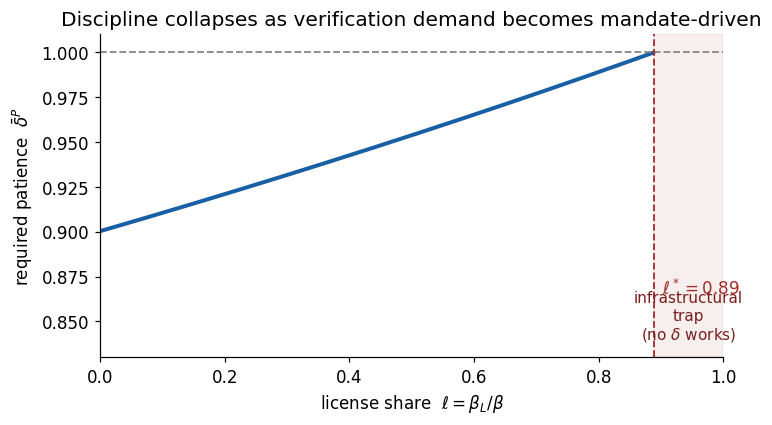

In [3]:
ells = np.linspace(0, 1, 400)
thr  = thr_vec(ells, cal['mu0'], cal['c'], cal['p'], cal['beta'], cal['rI'], cal['rL'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.axvspan(ellstar, 1, color='#A32D2D', alpha=0.08)
ax.plot(ells, thr, color='#185FA5', lw=2.6)
ax.axhline(1, ls='--', color='#888', lw=1.2)
ax.axvline(ellstar, ls='--', color='#A32D2D', lw=1.2)
ax.text(ellstar+0.012, 0.865, rf"$\ell^*={ellstar:.2f}$", color='#A32D2D')
ax.text((ellstar+1)/2, 0.84, "infrastructural\ntrap\n(no $\\delta$ works)",
        ha='center', color='#791F1F', fontsize=10)
ax.set(xlabel=r"license share  $\ell=\beta_L/\beta$",
       ylabel=r"required patience  $\bar\delta^P$", xlim=(0,1), ylim=(0.83,1.01))
ax.set_title("Discipline collapses as verification demand becomes mandate-driven")
plt.tight_layout(); plt.show()


## 4. Detection is not a substitute for incentives

A central applied point: **$\ell^\star$ does not depend on $p$.** More auditing/exposure ($p\uparrow$) lowers the required
patience *where discipline is feasible*, but it **cannot move the trap boundary**. You cannot audit your way out of a
license-driven label — the curve shifts down, the cliff stays put.


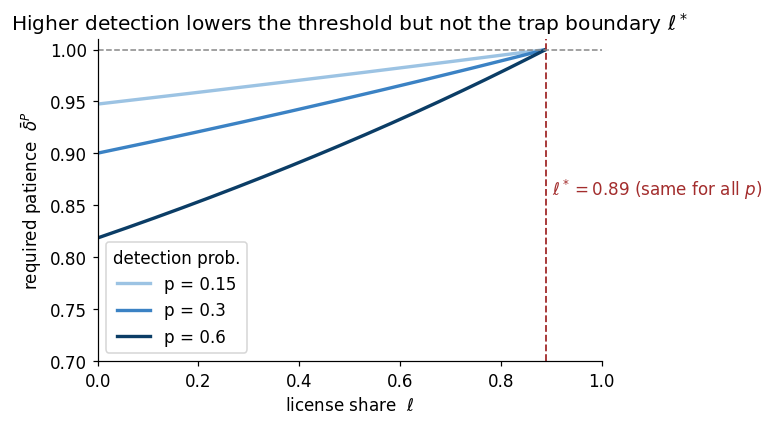

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
for p, col in [(0.15,'#9CC3E3'), (0.30,'#3B82C4'), (0.60,'#0B3D66')]:
    c2 = {**cal, 'p':p}
    ax.plot(ells, thr_vec(ells, c2['mu0'],c2['c'],c2['p'],c2['beta'],c2['rI'],c2['rL']),
            lw=2.2, color=col, label=f"p = {p}")
ax.axvline(ellstar, ls='--', color='#A32D2D', lw=1.2)
ax.text(ellstar+0.012, 0.86, rf"$\ell^*={ellstar:.2f}$ (same for all $p$)", color='#A32D2D')
ax.axhline(1, ls='--', color='#888', lw=1.0)
ax.set(xlabel=r"license share  $\ell$", ylabel=r"required patience  $\bar\delta^P$",
       xlim=(0,1), ylim=(0.7,1.01)); ax.legend(title="detection prob.")
ax.set_title("Higher detection lowers the threshold but not the trap boundary $\\ell^*$")
plt.tight_layout(); plt.show()


## 5. Comparative statics of the trap boundary $\ell^\star$

- **Stickier license** ($\rho_L\uparrow$) $\Rightarrow$ $\ell^\star\downarrow$: the trap bites earlier.
- **Higher cost of passing bad inventory** ($c\uparrow$) $\Rightarrow$ $\ell^\star\uparrow$: liability protects.
- **Higher-quality pool** ($\mu_0\uparrow$) $\Rightarrow$ $\ell^\star\uparrow$: clean inventory is protective.

When $\ell^\star\ge 1$ the trap never bites in the admissible range — a label can be entirely license-driven yet still disciplinable.


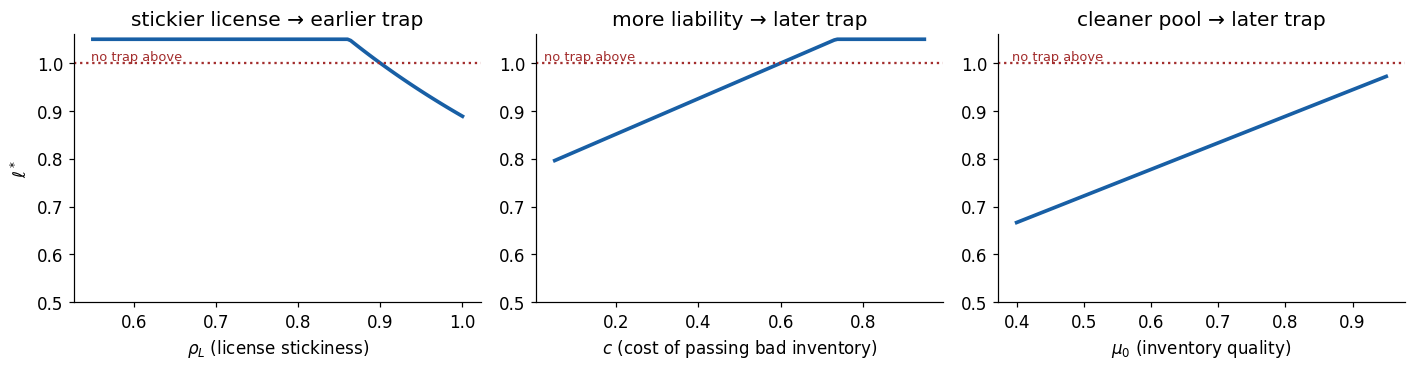

In [5]:
def clip1(v):  # show ell* but cap display at 1.05 (values >1 mean 'no trap')
    return np.minimum(v, 1.05)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
rLs = np.linspace(0.55, 1.0, 120)
cs  = np.linspace(0.05, 0.95, 120)
mus = np.linspace(0.40, 0.95, 120)

axes[0].plot(rLs, clip1([license_share_star(0.8,0.3,0.6,0.1,r) for r in rLs]), color='#185FA5', lw=2.4)
axes[0].set(xlabel=r"$\rho_L$ (license stickiness)", ylabel=r"$\ell^*$", title="stickier license → earlier trap")
axes[1].plot(cs,  clip1([license_share_star(0.8,c,0.6,0.1,1.0) for c in cs]), color='#185FA5', lw=2.4)
axes[1].set(xlabel=r"$c$ (cost of passing bad inventory)", title="more liability → later trap")
axes[2].plot(mus, clip1([license_share_star(m,0.3,0.6,0.1,1.0) for m in mus]), color='#185FA5', lw=2.4)
axes[2].set(xlabel=r"$\mu_0$ (inventory quality)", title="cleaner pool → later trap")
for ax in axes:
    ax.axhline(1.0, ls=':', color='#A32D2D'); ax.set_ylim(0.5,1.06)
    ax.text(ax.get_xlim()[0]+0.02, 1.005, "no trap above", color='#A32D2D', fontsize=8.5)
plt.tight_layout(); plt.show()


## 6. Where the trap lives: the $(\ell,\rho_L)$ map

Required patience over license share $\ell$ and license stickiness $\rho_L$. The red region is the **infrastructural trap**
(no discount factor sustains honesty). It expands as license demand becomes stickier — the empirically relevant direction
for mandated / compliance-driven verification spend.


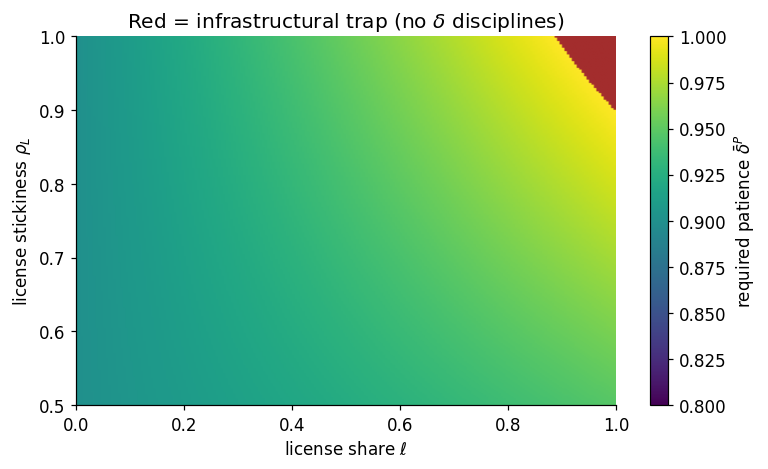

In [6]:
ng = 220
ELL = np.linspace(0, 1, ng)
RL  = np.linspace(0.5, 1.0, ng)
Z = np.empty((ng, ng))
for i, r in enumerate(RL):
    for j, e in enumerate(ELL):
        Z[i, j] = patience_threshold(e, cal['mu0'], cal['c'], cal['p'], cal['beta'], cal['rI'], r)
Zm = np.ma.masked_invalid(Z)

cmap = plt.cm.viridis.copy(); cmap.set_bad('#A32D2D')
fig, ax = plt.subplots(figsize=(7.2, 4.4))
im = ax.imshow(Zm, origin='lower', aspect='auto', cmap=cmap,
               extent=[ELL.min(), ELL.max(), RL.min(), RL.max()], vmin=0.8, vmax=1.0)
cb = fig.colorbar(im, ax=ax); cb.set_label(r"required patience $\bar\delta^P$")
ax.set(xlabel=r"license share $\ell$", ylabel=r"license stickiness $\rho_L$",
       title="Red = infrastructural trap (no $\\delta$ disciplines)")
plt.tight_layout(); plt.show()


## 7. Two testable predictions (ad-tech)

**Prediction A — Scandal pass-through falls with the mandated share of demand.**
After a public verification failure (an Adalytics-type exposure), the *drop in spend* directed to the implicated vendor is
decreasing in the share of that spend governed by contractual / compliance mandates. License demand does not flee;
informational demand does.
*Identification.* Event study around exposures, comparing advertisers with high vs low mandated-verification share
(from RFP/contract language or holding-company policy), with vendor×advertiser fixed effects; or a cross-vendor
diff-in-diff exploiting variation in how exposed each vendor was.

**Prediction B — Badges discipline only when their loss removes algorithmic eligibility.**
A "verified"/quality badge exerts reputational discipline on a seller/vendor only if losing it materially reduces
ranking, visibility, or auction eligibility. Where the badge is cosmetic (loss does not change placement),
post-exposure quality does not improve.
*Identification.* Compare platforms (or a within-platform policy change) where the badge gates ranking vs where it is
purely informational; regress a quality proxy (defect/complaint rate) on exposure × "badge-gates-eligibility".

Both map to one estimand: **post-scandal demand retention**, which the model identifies as the empirical proxy for the
license share $\ell$ (and for $\rho_L$).


## 8. What this companion demonstrates

- Moving cleanly from a signaling / reputation model to a **calibrated, interpretable simulation**.
- A platform-incentives reading of **brand safety, ad verification, badges and ranking eligibility**.
- A non-obvious, decision-relevant result for governance: **detection ($p$) cannot fix a license-driven label** — only
  reducing mandated reliance or internalizing the access value (liability, platform design) moves the trap boundary.
- Two predictions with explicit identification, formulated in the language an ad-tech / platform-science team would use.
